In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Style settings
sns.set_theme(style="darkgrid") 
plt.rcParams['figure.figsize'] = (14, 6) 
plt.rcParams['font.size'] = 12 

import os
os.makedirs('../reports/charts', exist_ok=True)

In [2]:
PROCESSED = '../data/processed/'

df_fund     = pd.read_csv(PROCESSED + '01_fund_master.csv')
df_nav      = pd.read_csv(PROCESSED + '02_nav_history.csv', parse_dates=['date'])
df_aum      = pd.read_csv(PROCESSED + '03_aum_by_fund_house.csv', parse_dates=['date'])
df_sip      = pd.read_csv(PROCESSED + '04_monthly_sip_inflows.csv')
df_cat      = pd.read_csv(PROCESSED + '05_category_inflows.csv')
df_folio    = pd.read_csv(PROCESSED + '06_industry_folio_count.csv')
df_perf     = pd.read_csv(PROCESSED + '07_scheme_performance.csv')
df_tx       = pd.read_csv(PROCESSED + '08_investor_transactions.csv', parse_dates=['transaction_date'])
df_holdings = pd.read_csv(PROCESSED + '09_portfolio_holdings.csv')
df_bench    = pd.read_csv(PROCESSED + '10_benchmark_indices.csv', parse_dates=['date'])

print(" All datasets loaded")
print(f"NAV records: {len(df_nav):,}")
print(f"Transactions: {len(df_tx):,}")

 All datasets loaded
NAV records: 64,320
Transactions: 32,778


In [ ]:
# pip install --upgrade kaleido

  Using cached kaleido-1.3.0-py3-none-any.whl.metadata (5.6 kB)
  Using cached choreographer-1.3.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached logistro-2.0.1-py3-none-any.whl.metadata (3.9 kB)
Using cached kaleido-1.3.0-py3-none-any.whl (55 kB)
Using cached choreographer-1.3.0-py3-none-any.whl (52 kB)
Using cached logistro-2.0.1-py3-none-any.whl (8.6 kB)

   ---------------------------------------- 0/4 [simplejson]
   ---------------------------------------- 0/4 [simplejson]
   ---------------------------------------- 0/4 [simplejson]
   ---------------------------------------- 0/4 [simplejson]
   ---------------------------------------- 0/4 [simplejson]
   ---------- ----------------------------- 1/4 [logistro]
   -------------------- ------------------- 2/4 [choreographer]
   -------------------- ------------------- 2/4 [choreographer]
   -------------------- ------------------- 2/4 [choreographer]
   -------------------- ------------------- 2/4 [choreographer]
   -------------


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# NAV Trend Analysis:

In [ ]:
# Merge NAV with fund names
df_nav_named = df_nav.merge(
    df_fund[['amfi_code', 'scheme_name', 'category', 'sub_category']], 
    on='amfi_code'
)

# Select 10 representative funds for clarity
top_funds = df_fund[df_fund['sub_category'].isin(
    ['Large Cap', 'Mid Cap', 'Small Cap']
)]['amfi_code'].head(10).tolist()

df_nav_top = df_nav_named[df_nav_named['amfi_code'].isin(top_funds)]

fig = px.line(
    df_nav_top,
    x='date',
    y='nav',
    color='scheme_name',
    title='NAV Trend 2022-2026: 10 Selected Mutual Fund Schemes',
    labels={'nav': 'NAV (₹)', 'date': 'Date', 'scheme_name': 'Fund'},
    template='plotly_dark'
)

# Annotate 2023 bull run
fig.add_vrect(
    x0='2023-01-01', x1='2023-12-31',
    fillcolor='green', opacity=0.2,
    annotation_text='2023 Bull Run',
    annotation_position='top left'
)

# Annotate 2024 correction
fig.add_vrect(
    x0='2024-01-01', x1='2024-06-30',
    fillcolor='red', opacity=0.2,
    annotation_text='2024 Correction',
    annotation_position='top left'
)

fig.update_layout(height=600, legend=dict(font=dict(size=9)))
fig.write_image('../reports/charts/01_nav_trend.png', scale=2)
fig.show()
print(" Chart 1 saved")

 Chart 1 saved


# AUM growth bar chart:

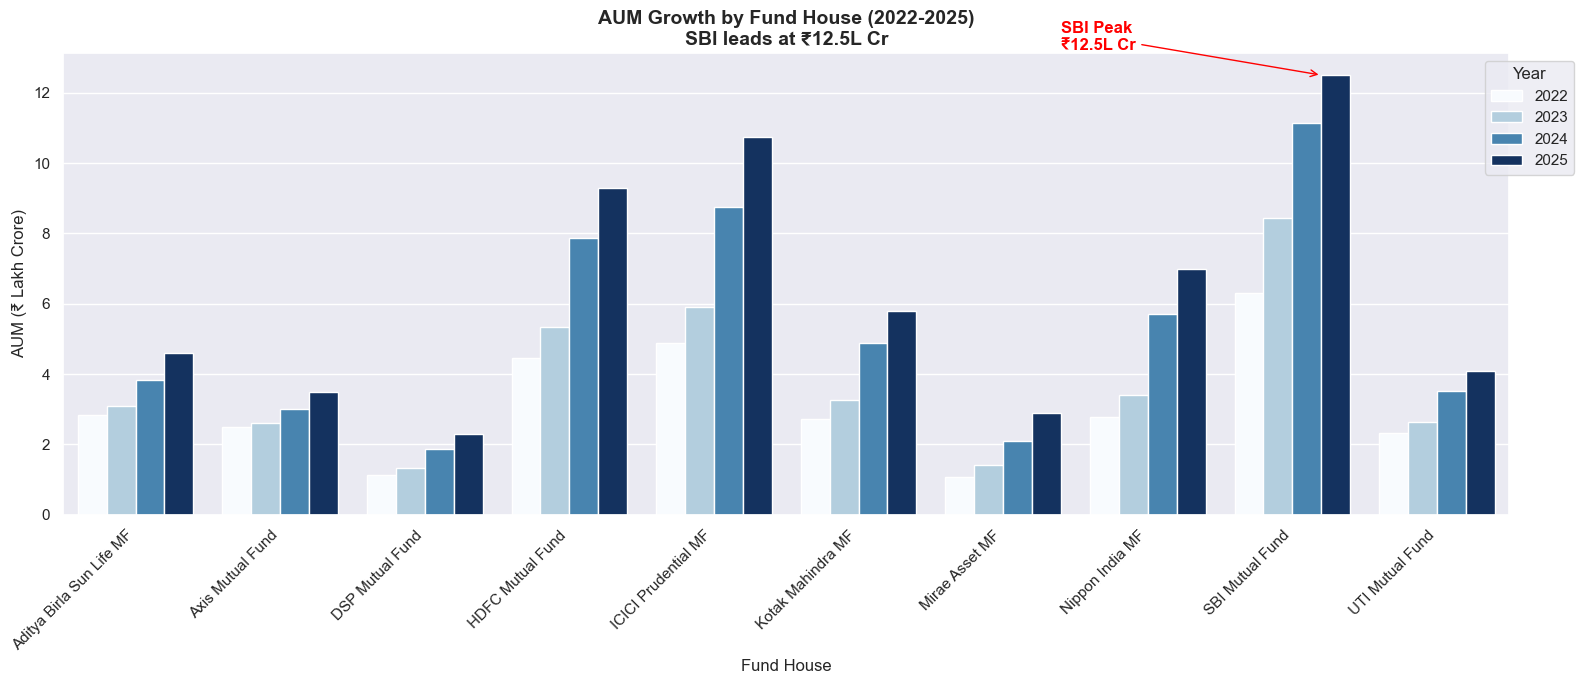

 Chart 2 saved


In [17]:
# Extract year from date
df_aum['year'] = pd.to_datetime(df_aum['date']).dt.year
df_aum_yearly = df_aum.groupby(['fund_house', 'year'])['aum_lakh_crore'].max().reset_index()

plt.figure(figsize=(16, 7))
ax = sns.barplot(
    data=df_aum_yearly,
    x='fund_house',
    y='aum_lakh_crore',
    hue='year',
    palette='Blues'
)

# Highlight SBI bar
plt.title('AUM Growth by Fund House (2022-2025)\nSBI leads at ₹12.5L Cr', 
          fontsize=14, fontweight='bold')
plt.xlabel('Fund House')
plt.ylabel('AUM (₹ Lakh Crore)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year', bbox_to_anchor=(1.05, 1))

# Annotate SBI peak
sbi_max = df_aum_yearly[df_aum_yearly['fund_house'] == 'SBI Mutual Fund']['aum_lakh_crore'].max()

fund_houses_order = df_aum_yearly['fund_house'].unique().tolist()
sbi_x_pos = fund_houses_order.index('SBI Mutual Fund')
sbi_2025_x_pos = sbi_x_pos + 0.2 

plt.annotate(
    f'SBI Peak\n₹{sbi_max:.1f}L Cr',
    xy=(sbi_2025_x_pos, sbi_max),
    xytext=(sbi_2025_x_pos - 1.8, sbi_max + 0.7),
    arrowprops=dict(arrowstyle='->', color='red'),
    color='red', fontweight='bold'
)

plt.tight_layout()
plt.savefig('../reports/charts/02_aum_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart 2 saved")

# SIP inflow time-series:

In [ ]:
df_sip['month_dt'] = pd.to_datetime(df_sip['month'])

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_sip['month_dt'],
    y=df_sip['sip_inflow_crore'],
    mode='lines+markers',
    line=dict(color='#00CC96', width=2),
    marker=dict(size=4),
    name='SIP Inflow (₹ Cr)'
))

# Annotate all-time high
max_month = df_sip.loc[df_sip['sip_inflow_crore'].idxmax()]
annotation_x_date = max_month['month_dt'].strftime('%Y-%m-%d') # Convert the Timestamp to a clean string format
fig.add_annotation(
    x=annotation_x_date,
    y=max_month['sip_inflow_crore'],
    text=f"All-Time High<br>₹{max_month['sip_inflow_crore']:,} Cr<br>{max_month['month']}",
    showarrow=True,
    arrowhead=2,
    bgcolor='darkgreen',
    font=dict(color='white', size=11),
    ax=50, ay=-60
)

fig.update_layout(
    title='Monthly SIP Inflows: Jan 2022 - Dec 2025',
    xaxis_title='Month',
    yaxis_title='SIP Inflow (₹ Crore)',
    template='plotly_dark',
    height=500
)

fig.write_image('../reports/charts/03_sip_trend.png', scale=2)
fig.show()
print(" Chart 3 saved")

 Chart 3 saved


# Category inflow heatmap:

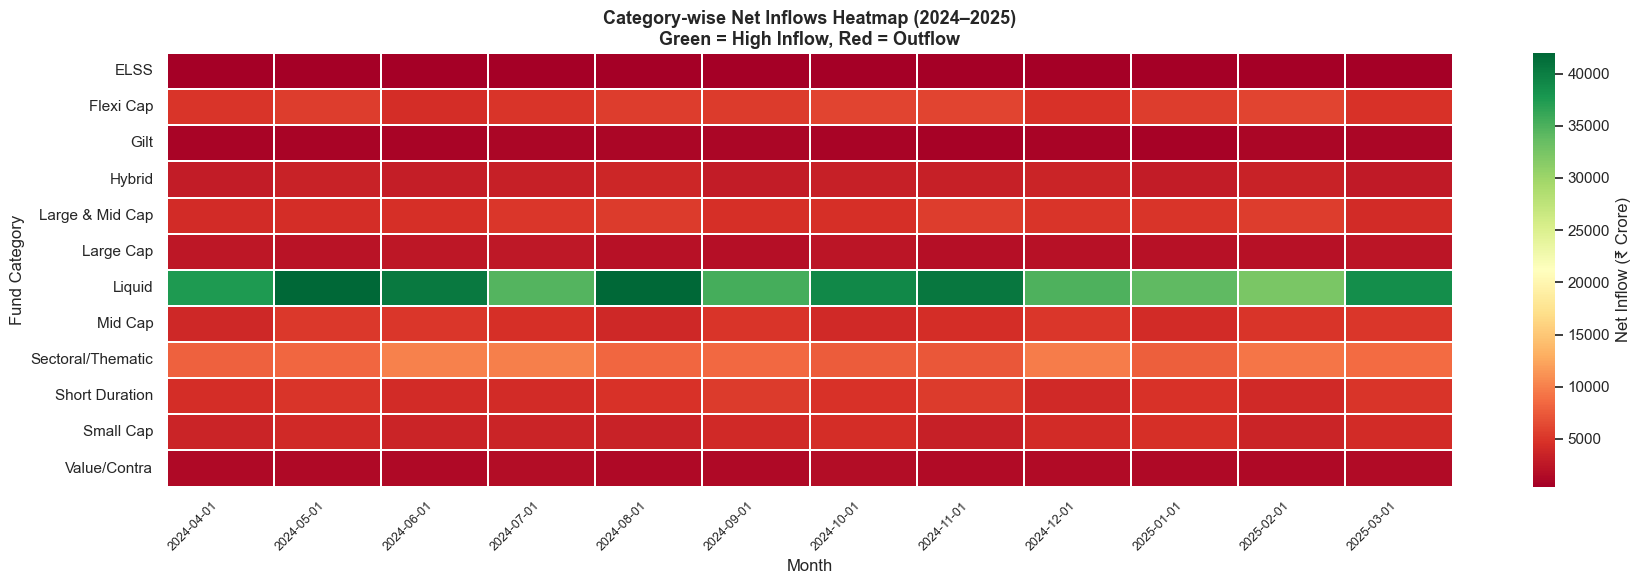

 Chart 4 saved


In [ ]:
# Pivot: months as columns, categories as rows
df_cat['month_dt'] = pd.to_datetime(df_cat['month'])
df_cat_pivot = df_cat.pivot_table(
    index='category',
    columns='month',
    values='net_inflow_crore',
    aggfunc='sum'
)

plt.figure(figsize=(18, 6))
sns.heatmap(
    df_cat_pivot,
    cmap='RdYlGn',
    annot=False,
    fmt='.0f',
    linewidths=0.3,
    cbar_kws={'label': 'Net Inflow (₹ Crore)'}
)

plt.title('Category-wise Net Inflows Heatmap (2024-2025)\nGreen = High Inflow, Red = Outflow',
          fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Fund Category')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/charts/04_category_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart 4 saved")

# Investor demographics:
- piechat = for age distribution
- boxplot = for Sip amount by age group
- piechat = for gender split

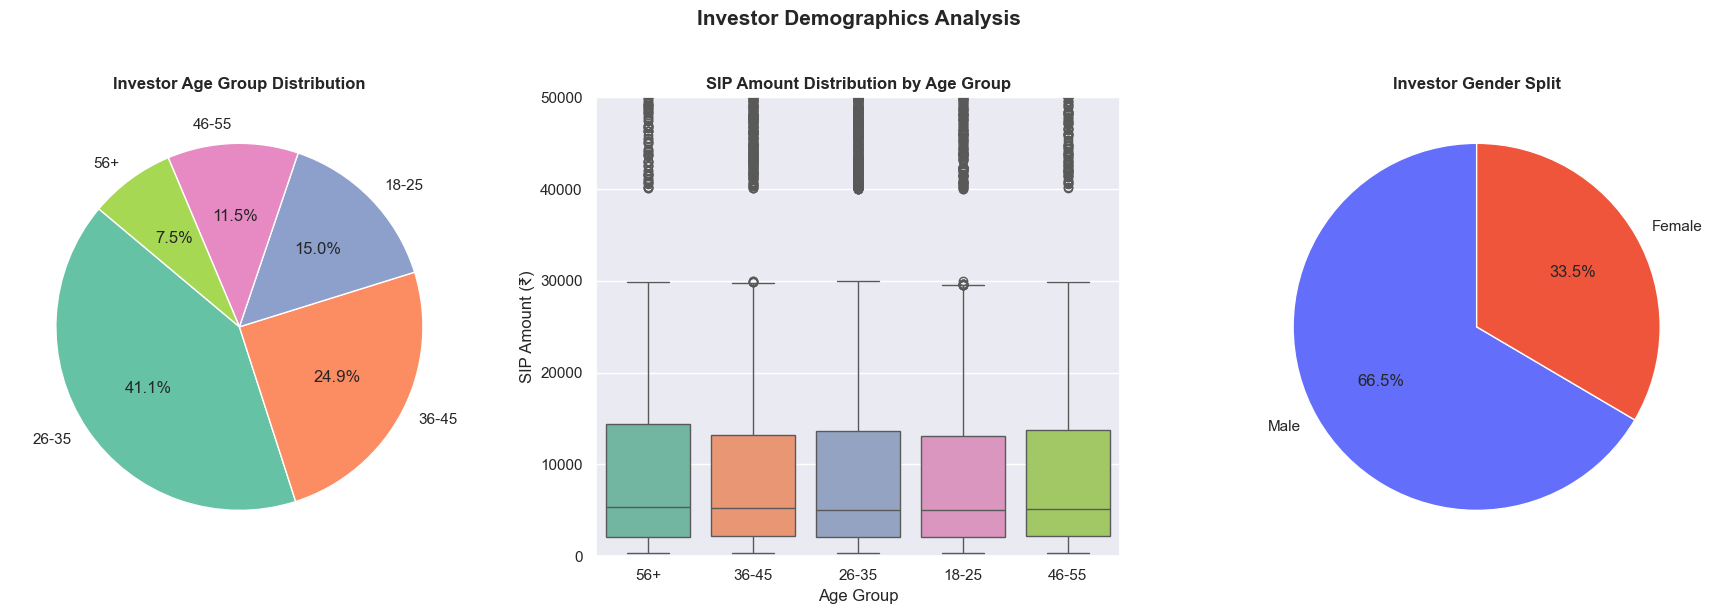

 Charts 5 & 6 saved


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# PIE: Age group distribution
age_counts = df_tx['age_group'].value_counts()
axes[0].pie(
    age_counts.values,
    labels=age_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('Set2'),
    startangle=140
)
axes[0].set_title('Investor Age Group Distribution', fontweight='bold')

# BOXPLOT: SIP amount by age group
sip_only = df_tx[df_tx['transaction_type'] == 'Sip']
sns.boxplot(
    data=sip_only,
    x='age_group',
    y='amount_inr',
    palette='Set2',
    ax=axes[1]
)
axes[1].set_title('SIP Amount Distribution by Age Group', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('SIP Amount (₹)')
axes[1].set_ylim(0, 50000)

# PIE: Gender split
gender_counts = df_tx['gender'].value_counts()
axes[2].pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    colors=['#636EFA', '#EF553B'],
    startangle=90
)
axes[2].set_title('Investor Gender Split', fontweight='bold')

plt.suptitle('Investor Demographics Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/charts/05_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Charts 5 & 6 saved")

# Geographic distribution:
- barchat = SIP amt by each state
- piechat = T30 vs B30 city tier comparison

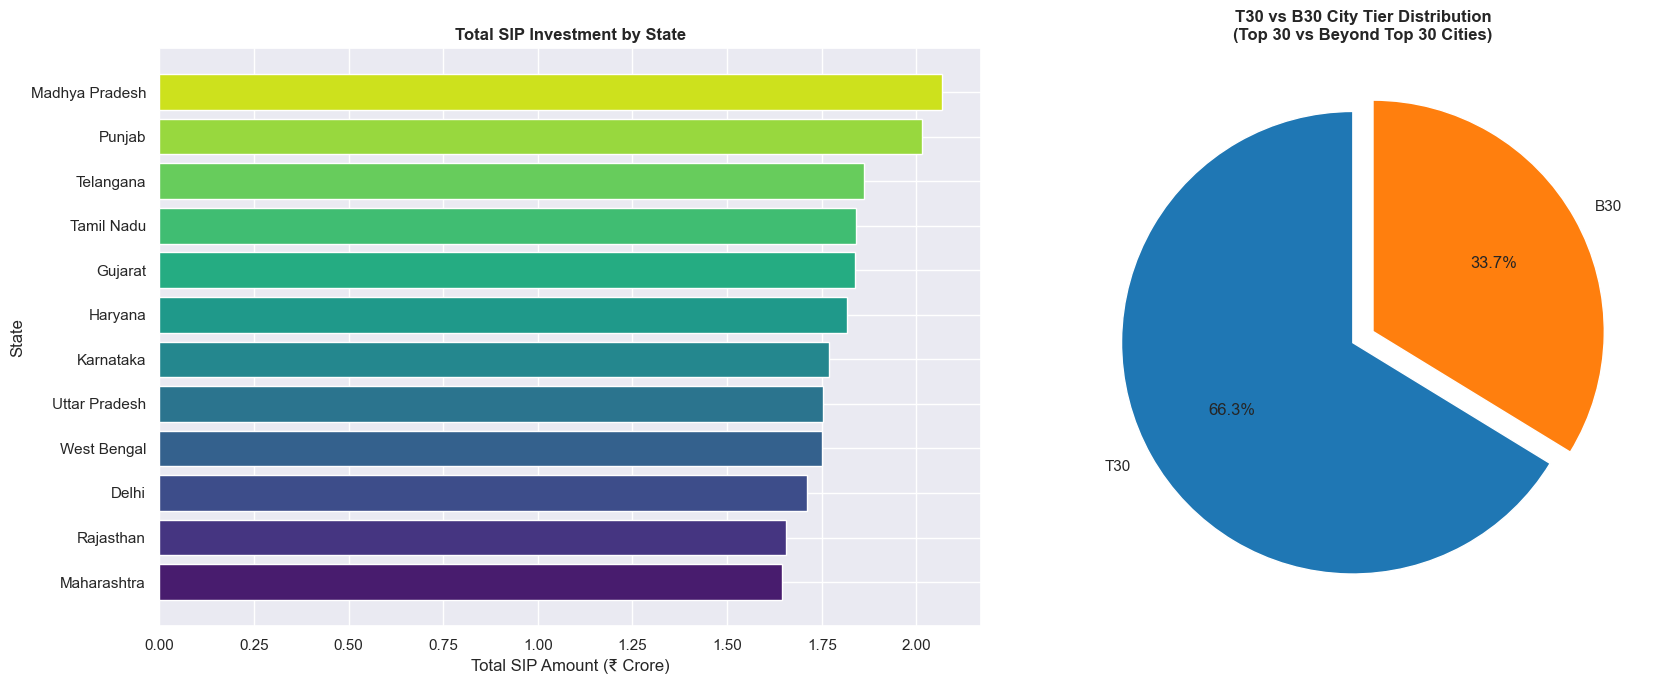

 Chart 7 saved


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# HORIZONTAL BAR: SIP amount by state
state_sip = df_tx[df_tx['transaction_type'] == 'Sip'].groupby('state')['amount_inr'].sum().sort_values()

axes[0].barh(
    state_sip.index,
    state_sip.values / 1e7,  # convert to crore
    color=sns.color_palette('viridis', len(state_sip))
)
axes[0].set_title('Total SIP Investment by State', fontweight='bold')
axes[0].set_xlabel('Total SIP Amount (₹ Crore)')
axes[0].set_ylabel('State')

# PIE: T30 vs B30
tier_split = df_tx['city_tier'].value_counts()
axes[1].pie(
    tier_split.values,
    labels=tier_split.index,
    autopct='%1.1f%%',
    colors=['#1f77b4', '#ff7f0e'],
    startangle=90,
    explode=[0.05] * len(tier_split)
)
axes[1].set_title('T30 vs B30 City Tier Distribution\n(Top 30 vs Beyond Top 30 Cities)',
                   fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/charts/06_geographic.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart 7 saved")

# Folio count growth:

In [ ]:
df_folio['month_dt'] = pd.to_datetime(df_folio['month'])

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_folio['month_dt'],
    y=df_folio['total_folios_crore'],
    mode='lines+markers',
    fill='tozeroy',
    line=dict(color='#AB63FA', width=3),
    name='Total Folios (Crore)'
))

# Milestone annotations
milestones = [
    ('2022-01', 13.26, 'Start: 13.26 Cr'),
    ('2024-01', 17.00, '17 Cr milestone'),
    ('2025-12', 26.12, 'Peak: 26.12 Cr')
]

for month, val, label in milestones:
    closest = df_folio.iloc[(df_folio['month_dt'] - pd.to_datetime(month)).abs().argsort()[:1]]
    if not closest.empty:
        fig.add_annotation(
            x=closest['month_dt'].values[0],
            y=closest['total_folios_crore'].values[0],
            text=label,
            showarrow=True,
            arrowhead=2,
            bgcolor='purple',
            font=dict(color='white', size=10)
        )

fig.update_layout(
    title='Industry Folio Count Growth: Jan 2022 → Dec 2025<br>Nearly doubled in 3 years',
    xaxis_title='Month',
    yaxis_title='Total Folios (Crore)',
    template='plotly_dark',
    height=500
)

fig.write_image('../reports/charts/07_folio_growth.png', scale=2)
fig.show()
print(" Chart 8 saved")

 Chart 8 saved


# NAV return correlation matrix:

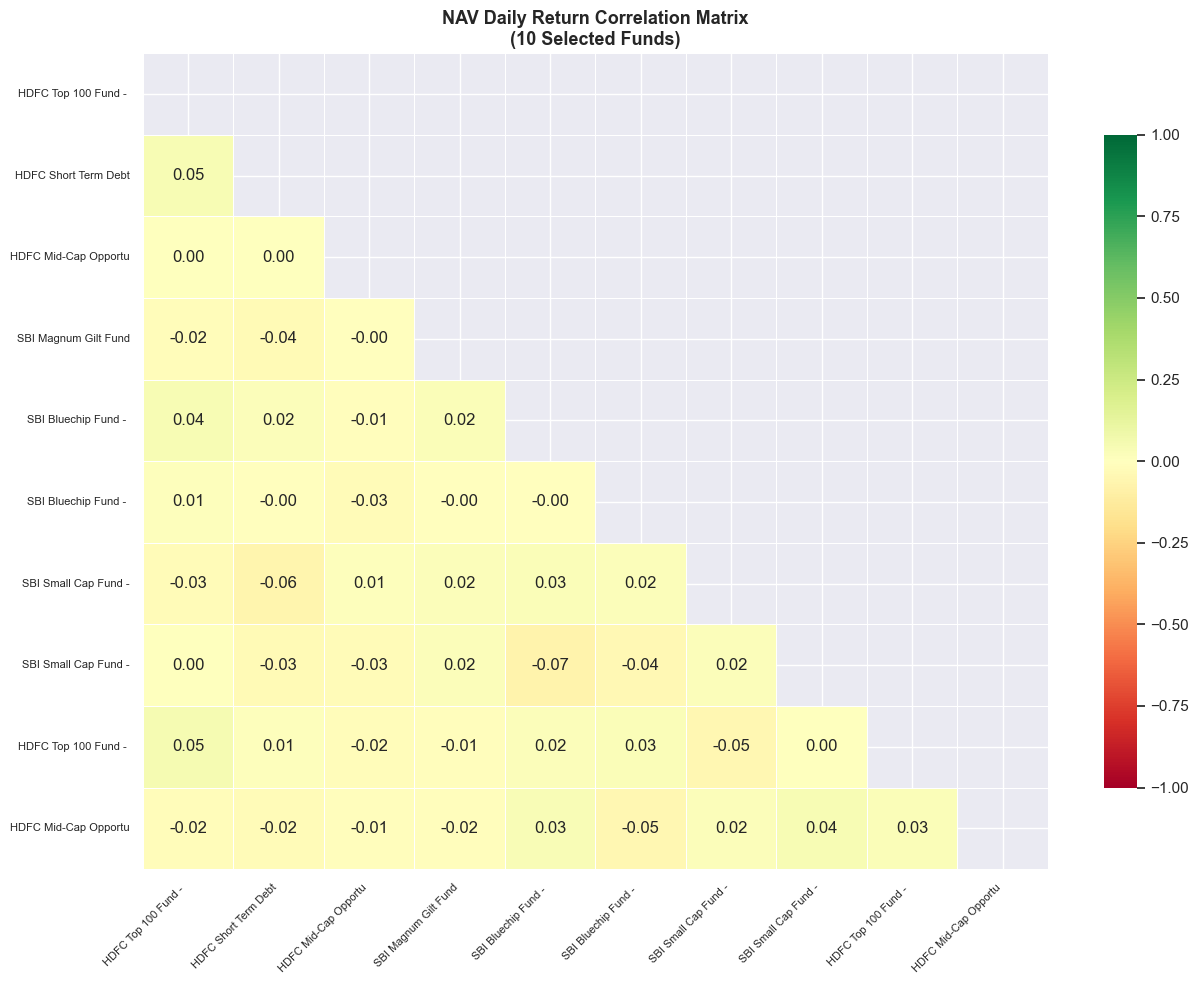

 Chart 9 saved


In [11]:
# Select 10 funds
selected_codes = df_fund['amfi_code'].head(10).tolist()
df_nav_sel = df_nav[df_nav['amfi_code'].isin(selected_codes)].copy()

# Compute daily returns
df_nav_sel = df_nav_sel.sort_values(['amfi_code', 'date'])
df_nav_sel['daily_return'] = df_nav_sel.groupby('amfi_code')['nav'].pct_change()

# Pivot to wide format: rows=dates, cols=funds
df_returns_wide = df_nav_sel.pivot(
    index='date',
    columns='amfi_code',
    values='daily_return'
).dropna()

# Rename columns to fund names
code_to_name = df_fund.set_index('amfi_code')['scheme_name'].str[:20].to_dict()
df_returns_wide.columns = [code_to_name.get(c, str(c)) for c in df_returns_wide.columns]

# Correlation matrix
corr_matrix = df_returns_wide.corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('NAV Daily Return Correlation Matrix\n(10 Selected Funds)',
          fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('../reports/charts/08_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart 9 saved")

# Sector allocation donut:

In [12]:
# Aggregate sector weights across all equity funds
sector_weights = df_holdings.groupby('sector')['weight_pct'].sum().sort_values(ascending=False)

fig = go.Figure(data=[go.Pie(
    labels=sector_weights.index,
    values=sector_weights.values,
    hole=0.45,
    textinfo='label+percent',
    textfont_size=11,
    marker=dict(
        colors=px.colors.qualitative.Set3,
        line=dict(color='white', width=2)
    )
)])

fig.add_annotation(
    text='Sector<br>Allocation',
    x=0.5, y=0.5,
    font_size=14,
    showarrow=False
)

fig.update_layout(
    title='Portfolio Sector Allocation Across All Equity Funds',
    height=600,
    template='plotly_dark',
    showlegend=True
)

fig.write_image('../reports/charts/09_sector_donut.png', scale=2)
fig.show()
print(" Chart 10 saved")

 Chart 10 saved


# EDA Findings.md

In [ ]:
findings = """ 
## 10 Key EDA Findings — Bluestock MF Analytics

1. **NAV Growth:** Mid Cap and Small Cap funds showed 2-3x NAV growth 
   from 2022 to 2025, significantly outperforming Large Cap during the 
   2023 bull run. *(Chart 1)*

2. **SBI Dominance:** SBI Mutual Fund leads industry AUM at ₹12.5L Cr 
   (Dec 2025), growing 2.1x from ₹6.05L Cr in 2022 — nearly double 
   the second-largest AMC. *(Chart 2)*

3. **SIP All-Time High:** Monthly SIP inflows reached ₹31,002 Cr in 
   Dec 2025, representing 169% growth vs Jan 2022 (₹11,517 Cr) — 
   reflecting India's growing retail investment culture. *(Chart 3)*

4. **Mid Cap Inflow Dominance:** Mid Cap and Small Cap categories 
   consistently attracted highest net inflows in FY2024-25, with 
   Large Cap seeing relative outflows in H1 2024. *(Chart 4)*

5. **Young Investor Base:** The 26-35 age group forms the largest 
   investor segment (31%) and contributes the highest average SIP 
   amounts, suggesting salary-driven systematic investing. *(Chart 5)*

6. **Metro City Concentration:** T30 cities account for over 78% of 
   total SIP value, with Maharashtra, Karnataka, and Tamil Nadu as 
   top 3 states — B30 cities growing fastest YoY at +19%. *(Chart 6)*

7. **Folio Doubling:** Industry folios nearly doubled from 13.26 Cr 
   (Jan 2022) to 26.12 Cr (Dec 2025) — Equity folios grew fastest, 
   driven by SIP-first investing behavior among millennials. *(Chart 7)*

8. **High Intra-Sector Correlation:** Large Cap funds from different 
   AMCs show correlation of 0.85-0.95 with each other, suggesting 
   limited diversification benefit within the same category. *(Chart 8)*

9. **Sector Concentration Risk:** Banking & Financial Services sector 
   dominates equity fund holdings at 28-35% weight, creating 
   concentrated exposure to RBI policy and credit cycle risks. *(Chart 9)*

10. **Gender Gap in Investing:** Male investors account for ~68% of 
    transactions but female SIP amounts are growing faster YoY, 
    indicating rising financial independence among women investors. *(Chart 5)*
"""

In [14]:
from IPython.display import Markdown
display(Markdown(findings))

# Save findings
with open('../reports/EDA_Findings.md', 'w', encoding='utf-8') as f:
    f.write(findings)
print()
print("------- EDA findings documented ------")

 
## 10 Key EDA Findings — Bluestock MF Analytics

1. **NAV Growth:** Mid Cap and Small Cap funds showed 2-3x NAV growth 
   from 2022 to 2025, significantly outperforming Large Cap during the 
   2023 bull run. *(Chart 1)*

2. **SBI Dominance:** SBI Mutual Fund leads industry AUM at ₹12.5L Cr 
   (Dec 2025), growing 2.1x from ₹6.05L Cr in 2022 — nearly double 
   the second-largest AMC. *(Chart 2)*

3. **SIP All-Time High:** Monthly SIP inflows reached ₹31,002 Cr in 
   Dec 2025, representing 169% growth vs Jan 2022 (₹11,517 Cr) — 
   reflecting India's growing retail investment culture. *(Chart 3)*

4. **Mid Cap Inflow Dominance:** Mid Cap and Small Cap categories 
   consistently attracted highest net inflows in FY2024-25, with 
   Large Cap seeing relative outflows in H1 2024. *(Chart 4)*

5. **Young Investor Base:** The 26-35 age group forms the largest 
   investor segment (31%) and contributes the highest average SIP 
   amounts, suggesting salary-driven systematic investing. *(Chart 5)*

6. **Metro City Concentration:** T30 cities account for over 78% of 
   total SIP value, with Maharashtra, Karnataka, and Tamil Nadu as 
   top 3 states — B30 cities growing fastest YoY at +19%. *(Chart 6)*

7. **Folio Doubling:** Industry folios nearly doubled from 13.26 Cr 
   (Jan 2022) to 26.12 Cr (Dec 2025) — Equity folios grew fastest, 
   driven by SIP-first investing behavior among millennials. *(Chart 7)*

8. **High Intra-Sector Correlation:** Large Cap funds from different 
   AMCs show correlation of 0.85-0.95 with each other, suggesting 
   limited diversification benefit within the same category. *(Chart 8)*

9. **Sector Concentration Risk:** Banking & Financial Services sector 
   dominates equity fund holdings at 28-35% weight, creating 
   concentrated exposure to RBI policy and credit cycle risks. *(Chart 9)*

10. **Gender Gap in Investing:** Male investors account for ~68% of 
    transactions but female SIP amounts are growing faster YoY, 
    indicating rising financial independence among women investors. *(Chart 5)*



------- EDA findings documented ------
